# 03 - 概率与统计基础：用不确定性理解机器学习

> 配套脚本：`01_math_foundations/03_probability_statistics.py`

本 Notebook 不是对原脚本的逐行搬运，而是围绕“机器学习为什么离不开概率”重新组织的教程版。

你会看到：

1. 概率不是玄学，而是对不确定性的量化
2. 条件概率和贝叶斯定理如何“用证据更新信念”
3. 常见分布如何描述数据生成过程
4. 期望、方差、标准化为什么是建模前的基本功
5. 最大似然估计如何连接“统计估计”和“模型训练”
6. 熵、交叉熵为什么会成为分类模型的损失函数

学习建议：运行每个代码单元，观察图像和数值变化；然后尝试修改参数，例如样本量、先验概率、方差或 logits。

In [4]:
# 环境准备
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

print(f"random generator: {rng}")

random generator: Generator(PCG64)


## 1. 概率的直觉：长期频率与主观信念

概率 $P(A)$ 表示事件 $A$ 发生的可能性，范围在 $[0,1]$ 之间：

- $P(A)=0$：不可能发生
- $P(A)=1$：一定发生
- $P(A)=0.7$：在同类条件下大约 70% 的机会发生

概率有两种常见理解：

| 视角 | 含义 | 例子 |
|---|---|---|
| 频率派 | 重复实验很多次后，事件出现的比例 | 公平骰子掷出 6 的长期比例约为 $1/6$ |
| 贝叶斯派 | 在已有信息下，对命题真实性的信念程度 | 看到邮件含“免费”后，判断它是垃圾邮件的概率 |

机器学习两种视角都会用到：数据通常被看作从某个分布采样而来；模型输出也常被解释成类别概率。

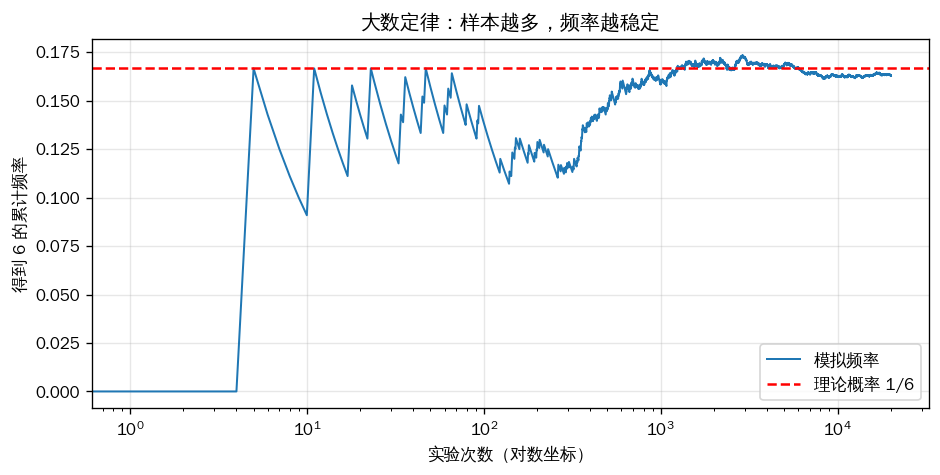

最后的模拟频率: 0.1628
理论概率:       0.1667


In [5]:
# 大数定律演示：掷骰子得到 6 的频率会逐渐接近理论概率 1/6
n_trials = 20_000
rolls = rng.integers(1, 7, size=n_trials)
is_six = (rolls == 6)
running_freq = np.cumsum(is_six) / np.arange(1, n_trials + 1)

plt.figure(figsize=(9, 4))
plt.plot(running_freq, lw=1.2, label='模拟频率')
plt.axhline(1/6, color='red', ls='--', label='理论概率 1/6')
plt.xscale('log')
plt.xlabel('实验次数（对数坐标）')
plt.ylabel('得到 6 的累计频率')
plt.title('大数定律：样本越多，频率越稳定')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'最后的模拟频率: {running_freq[-1]:.4f}')
print(f'理论概率:       {1/6:.4f}')

### 1.1 样本空间、事件与概率规则

概率问题通常先定义：

- **样本空间** $\Omega$：所有可能结果的集合
- **事件** $A$：样本空间的一个子集
- **概率** $P(A)$：事件 $A$ 中结果出现的可能性总和

两个最常用规则：

$$
P(A \cup B)=P(A)+P(B)-P(A\cap B)
$$

$$
P(A \cap B)=P(A)P(B|A)
$$

如果 $A$ 和 $B$ 独立，则：

$$
P(A\cap B)=P(A)P(B)
$$

注意：互斥和独立不是一回事。

- 互斥：两个事件不能同时发生
- 独立：知道一个事件发生，不改变另一个事件发生的概率

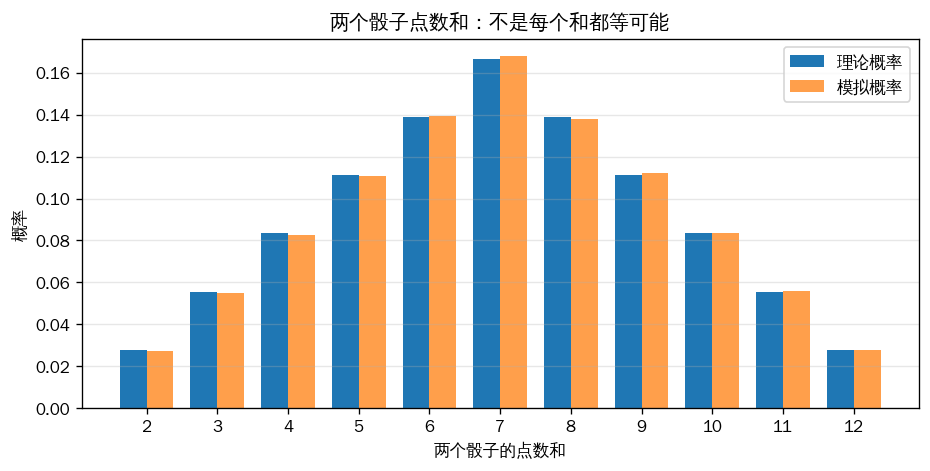

P(和为7) 理论值: 0.16666666666666666
P(和为7) 模拟值: 0.16779


In [6]:
# 两个骰子之和的完整概率分布
n = 100_000
dice1 = rng.integers(1, 7, size=n)
dice2 = rng.integers(1, 7, size=n)
sums = dice1 + dice2

possible_sums = np.arange(2, 13)
sim_probs = np.array([(sums == s).mean() for s in possible_sums])
theory_counts = np.array([1,2,3,4,5,6,5,4,3,2,1])
theory_probs = theory_counts / 36

plt.figure(figsize=(9, 4))
width = 0.38
plt.bar(possible_sums - width/2, theory_probs, width=width, label='理论概率')
plt.bar(possible_sums + width/2, sim_probs, width=width, label='模拟概率', alpha=0.75)
plt.xticks(possible_sums)
plt.xlabel('两个骰子的点数和')
plt.ylabel('概率')
plt.title('两个骰子点数和：不是每个和都等可能')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print('P(和为7) 理论值:', 6/36)
print('P(和为7) 模拟值:', sim_probs[possible_sums.tolist().index(7)])

### 1.2 独立性：不能只凭直觉判断

两个事件 $A$ 和 $B$ 独立，当且仅当：

$$
P(A|B)=P(A)
$$

也等价于：

$$
P(A\cap B)=P(A)P(B)
$$

例子：

- 第一个骰子是否为 6，与第二个骰子是否为 6：独立
- 第一个骰子是否为 6，与两个骰子之和是否至少为 10：不独立

因为如果已经知道两个骰子的和很大，那么第一个骰子更可能是较大的点数。

In [7]:
# 用模拟检查独立性
n = 200_000
d1 = rng.integers(1, 7, size=n)
d2 = rng.integers(1, 7, size=n)

A = (d1 == 6)
B = (d2 == 6)
C = (d1 + d2 >= 10)

def prob(event):
    return np.mean(event)

def cond_prob(event, given):
    return np.mean(event[given])

print('A: 第一个骰子为6')
print('B: 第二个骰子为6')
print('C: 两个骰子和至少为10')
print()
print(f'P(A)       = {prob(A):.4f}')
print(f'P(A|B)     = {cond_prob(A, B):.4f}  ← 接近 P(A)，A 与 B 近似独立')
print(f'P(A|C)     = {cond_prob(A, C):.4f}  ← 明显更大，A 与 C 不独立')
print(f'理论 P(A|C)= 3/6 = {3/6:.4f}，因为和至少为10有6种组合，其中3种第一个骰子为6')

A: 第一个骰子为6
B: 第二个骰子为6
C: 两个骰子和至少为10

P(A)       = 0.1659
P(A|B)     = 0.1668  ← 接近 P(A)，A 与 B 近似独立
P(A|C)     = 0.5006  ← 明显更大，A 与 C 不独立
理论 P(A|C)= 3/6 = 0.5000，因为和至少为10有6种组合，其中3种第一个骰子为6


## 2. 条件概率：改变问题的“参考范围”

条件概率：

$$
P(A|B)=\frac{P(A\cap B)}{P(B)}
$$

它的关键不是公式，而是参考范围变了：

- $P(A)$：在全部样本中看 $A$ 的比例
- $P(A|B)$：只在 $B$ 已经发生的样本中看 $A$ 的比例

在数据分析中，很多误解都来自混淆了“总体比例”和“子群体比例”。

In [8]:
# 用一个小数据表理解条件概率：邮件是否垃圾、是否包含“免费”
# 行：真实类别；列：是否包含关键词
# spam & free, spam & not free, ham & free, ham & not free
counts = {
    ('垃圾邮件', '包含免费'): 180,
    ('垃圾邮件', '不含免费'): 20,
    ('正常邮件', '包含免费'): 70,
    ('正常邮件', '不含免费'): 730,
}

total = sum(counts.values())
spam = counts[('垃圾邮件', '包含免费')] + counts[('垃圾邮件', '不含免费')]
free = counts[('垃圾邮件', '包含免费')] + counts[('正常邮件', '包含免费')]
spam_and_free = counts[('垃圾邮件', '包含免费')]

p_spam = spam / total
p_free = free / total
p_spam_given_free = spam_and_free / free
p_free_given_spam = spam_and_free / spam

print(f'P(垃圾邮件)           = {p_spam:.3f}')
print(f'P(包含免费)           = {p_free:.3f}')
print(f'P(垃圾邮件 | 包含免费) = {p_spam_given_free:.3f}')
print(f'P(包含免费 | 垃圾邮件) = {p_free_given_spam:.3f}')
print('\n注意：P(A|B) 和 P(B|A) 通常不相等。')

P(垃圾邮件)           = 0.200
P(包含免费)           = 0.250
P(垃圾邮件 | 包含免费) = 0.720
P(包含免费 | 垃圾邮件) = 0.900

注意：P(A|B) 和 P(B|A) 通常不相等。


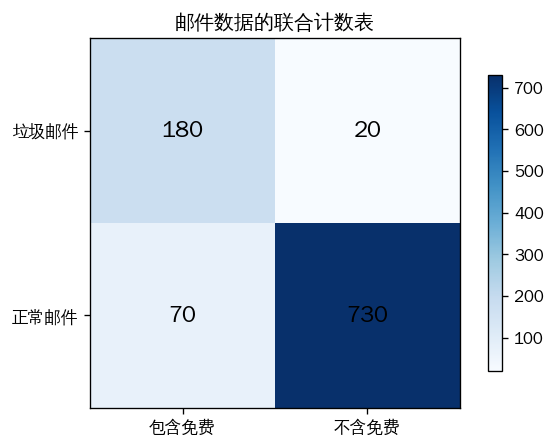

In [9]:
# 可视化上面的 2x2 计数表
matrix = np.array([
    [counts[('垃圾邮件', '包含免费')], counts[('垃圾邮件', '不含免费')]],
    [counts[('正常邮件', '包含免费')], counts[('正常邮件', '不含免费')]],
])

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(matrix, cmap='Blues')
ax.set_xticks([0, 1], labels=['包含免费', '不含免费'])
ax.set_yticks([0, 1], labels=['垃圾邮件', '正常邮件'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=14)
ax.set_title('邮件数据的联合计数表')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

## 3. 贝叶斯定理：用证据更新信念

贝叶斯定理来自条件概率的重排：

$$
P(A|B)=\frac{P(B|A)P(A)}{P(B)}
$$

更常见的机器学习语言是：

$$
\text{后验} = \frac{\text{似然} \times \text{先验}}{\text{证据}}
$$

| 名称 | 符号 | 含义 |
|---|---|---|
| 先验 | $P(A)$ | 看到新证据前对 $A$ 的信念 |
| 似然 | $P(B|A)$ | 如果 $A$ 为真，观察到证据 $B$ 的概率 |
| 证据 | $P(B)$ | 证据本身出现的总概率 |
| 后验 | $P(A|B)$ | 看到证据后对 $A$ 的新信念 |

它不是魔法，本质是“重新归一化”：在所有能产生证据的可能原因中，比较每个原因贡献了多少。

In [10]:
# 医学检测例子：低患病率下，阳性不等于大概率患病
prevalence = 0.01       # P(患病)
sensitivity = 0.99      # P(阳性 | 患病)
specificity = 0.95      # P(阴性 | 健康)
false_positive = 1 - specificity

p_positive = sensitivity * prevalence + false_positive * (1 - prevalence)
posterior = sensitivity * prevalence / p_positive

print(f'患病率 P(患病):              {prevalence:.2%}')
print(f'灵敏度 P(阳性|患病):          {sensitivity:.2%}')
print(f'误报率 P(阳性|健康):          {false_positive:.2%}')
print(f'总体阳性概率 P(阳性):          {p_positive:.2%}')
print(f'后验概率 P(患病|阳性):         {posterior:.2%}')

患病率 P(患病):              1.00%
灵敏度 P(阳性|患病):          99.00%
误报率 P(阳性|健康):          5.00%
总体阳性概率 P(阳性):          5.94%
后验概率 P(患病|阳性):         16.67%


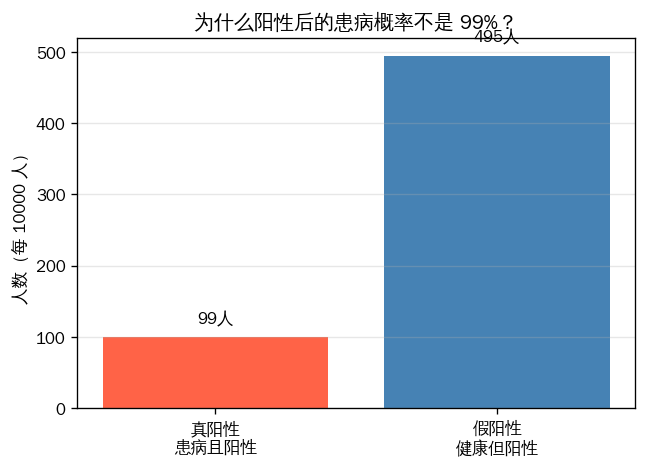

每 10000 人中：
  真阳性约 99 人
  假阳性约 495 人
  阳性者中真正患病比例 = 16.67%


In [11]:
# 用“自然频数”解释贝叶斯定理：比百分比更直观
population = 10_000
sick = population * prevalence
healthy = population - sick
true_positive = sick * sensitivity
false_positive_count = healthy * false_positive
all_positive = true_positive + false_positive_count

labels = ['真阳性\n患病且阳性', '假阳性\n健康但阳性']
values = [true_positive, false_positive_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['tomato', 'steelblue'])
plt.ylabel('人数（每 10000 人）')
plt.title('为什么阳性后的患病概率不是 99%？')
for i, v in enumerate(values):
    plt.text(i, v + 20, f'{v:.0f}人', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f'每 {population} 人中：')
print(f'  真阳性约 {true_positive:.0f} 人')
print(f'  假阳性约 {false_positive_count:.0f} 人')
print(f'  阳性者中真正患病比例 = {true_positive/all_positive:.2%}')

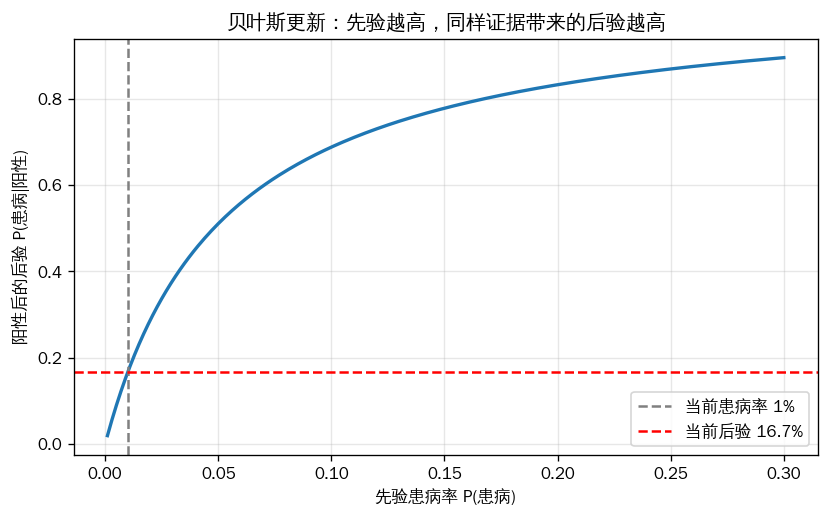

In [12]:
# 先验概率变化时，后验概率如何变化？
prevalences = np.linspace(0.001, 0.30, 300)
posteriors = (sensitivity * prevalences) / (sensitivity * prevalences + false_positive * (1 - prevalences))

plt.figure(figsize=(8, 4.5))
plt.plot(prevalences, posteriors, lw=2)
plt.axvline(prevalence, color='gray', ls='--', label='当前患病率 1%')
plt.axhline(posterior, color='red', ls='--', label=f'当前后验 {posterior:.1%}')
plt.xlabel('先验患病率 P(患病)')
plt.ylabel('阳性后的后验 P(患病|阳性)')
plt.title('贝叶斯更新：先验越高，同样证据带来的后验越高')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.1 朴素贝叶斯分类器的影子

在文本分类中，我们可能想计算：

$$
P(\text{垃圾邮件}|\text{包含“免费”}, \text{包含“中奖”})
$$

朴素贝叶斯会做一个强假设：给定类别后，各个词是否出现相互独立。

于是：

$$
P(\text{词1},\text{词2}|\text{类别}) \approx P(\text{词1}|\text{类别})P(\text{词2}|\text{类别})
$$

这个假设现实中不总是真的，但常常足够好，而且计算非常快。

In [13]:
# 一个极简朴素贝叶斯打分例子
classes = ['垃圾邮件', '正常邮件']
prior = {'垃圾邮件': 0.2, '正常邮件': 0.8}
likelihood = {
    '垃圾邮件': {'免费': 0.75, '中奖': 0.60, '会议': 0.05},
    '正常邮件': {'免费': 0.08, '中奖': 0.02, '会议': 0.30},
}
words = ['免费', '中奖']

scores = {}
for c in classes:
    score = prior[c]
    for w in words:
        score *= likelihood[c][w]
    scores[c] = score

normalizer = sum(scores.values())
posterior_scores = {c: s / normalizer for c, s in scores.items()}

print('邮件包含词:', words)
print('未归一化分数:', scores)
print('归一化后的类别概率:', posterior_scores)

邮件包含词: ['免费', '中奖']
未归一化分数: {'垃圾邮件': 0.09000000000000001, '正常邮件': 0.00128}
归一化后的类别概率: {'垃圾邮件': 0.985977212971078, '正常邮件': 0.014022787028921997}


## 4. 随机变量与概率分布

随机变量是把随机实验结果映射成数值的函数。例如：

- 掷骰子的点数 $X \in \{1,2,3,4,5,6\}$
- 一封邮件是否为垃圾邮件 $Y \in \{0,1\}$
- 用户身高 $H \in \mathbb{R}$

概率分布描述随机变量取不同值的概率。

| 类型 | 例子 | 描述方式 |
|---|---|---|
| 离散分布 | 骰子、类别标签、点击/未点击 | 概率质量函数 PMF |
| 连续分布 | 身高、噪声、模型误差 | 概率密度函数 PDF |

注意：连续变量某一个精确点的概率通常为 0，我们关心区间概率，例如 $P(160 < H < 180)$。

### 4.1 伯努利分布与二项分布

**伯努利分布**描述一次只有成功/失败的实验：

$$
X \sim \mathrm{Bernoulli}(p), \quad P(X=1)=p, \quad P(X=0)=1-p
$$

**二项分布**描述 $n$ 次独立伯努利实验中成功次数：

$$
X \sim \mathrm{Binomial}(n,p)
$$

$$
P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}
$$

很多机器学习问题都可以先粗略看成伯努利问题：点击/不点击、转化/不转化、正类/负类。

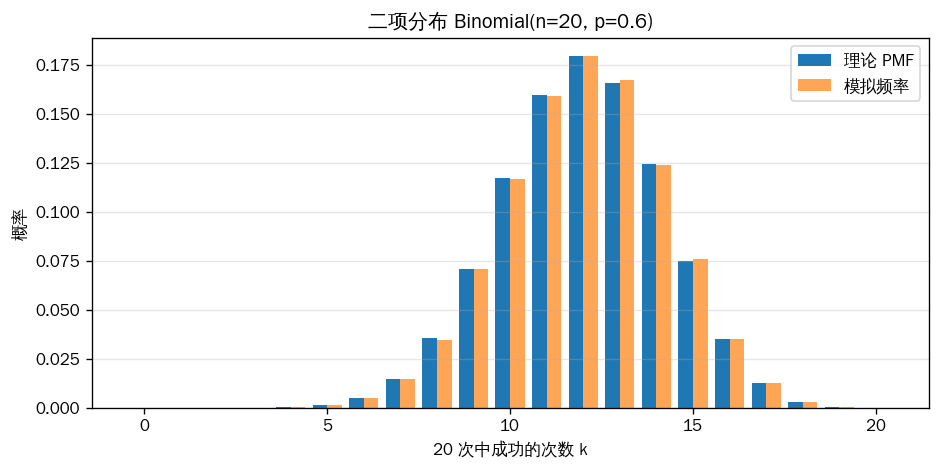

理论期望 np = 12.00
模拟均值     = 12.01


In [14]:
# 二项分布：抛 20 次硬币，正面次数的概率
n, p = 20, 0.6
ks = np.arange(n + 1)
pmf = np.array([math.comb(n, k) * p**k * (1-p)**(n-k) for k in ks])

sim = rng.binomial(n, p, size=100_000)
sim_pmf = np.array([(sim == k).mean() for k in ks])

plt.figure(figsize=(9, 4))
plt.bar(ks - 0.2, pmf, width=0.4, label='理论 PMF')
plt.bar(ks + 0.2, sim_pmf, width=0.4, label='模拟频率', alpha=0.7)
plt.xlabel('20 次中成功的次数 k')
plt.ylabel('概率')
plt.title('二项分布 Binomial(n=20, p=0.6)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f'理论期望 np = {n*p:.2f}')
print(f'模拟均值     = {sim.mean():.2f}')

### 4.2 均匀分布：没有偏好的基线

均匀分布表示所有可能结果等可能。

- 离散均匀：公平骰子每个点数概率相同
- 连续均匀：在区间 $[a,b]$ 内任意位置密度相同

它常被用作“没有更多信息时”的简单假设，也常用于随机初始化、随机采样和蒙特卡洛方法。

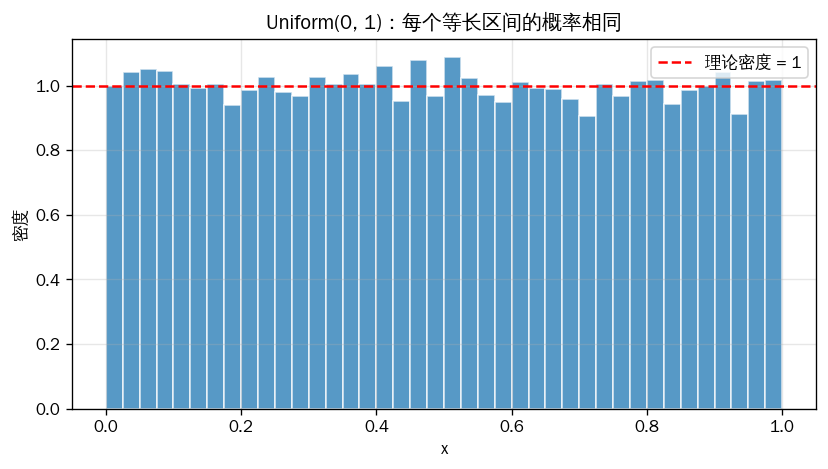

In [15]:
# 连续均匀分布：在 [0, 1] 上采样
samples = rng.uniform(0, 1, size=20_000)

plt.figure(figsize=(8, 4))
plt.hist(samples, bins=40, density=True, alpha=0.75, edgecolor='white')
plt.axhline(1.0, color='red', ls='--', label='理论密度 = 1')
plt.xlabel('x')
plt.ylabel('密度')
plt.title('Uniform(0, 1)：每个等长区间的概率相同')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.3 正态分布：自然数据与噪声的常见模型

正态分布也叫高斯分布：

$$
X \sim \mathcal{N}(\mu, \sigma^2)
$$

其密度为：

$$
f(x)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

两个参数的含义：

- $\mu$：中心位置，也就是均值
- $\sigma$：分散程度，也就是标准差

经验法则：

- 约 68% 数据落在 $\mu \pm 1\sigma$
- 约 95% 数据落在 $\mu \pm 2\sigma$
- 约 99.7% 数据落在 $\mu \pm 3\sigma$

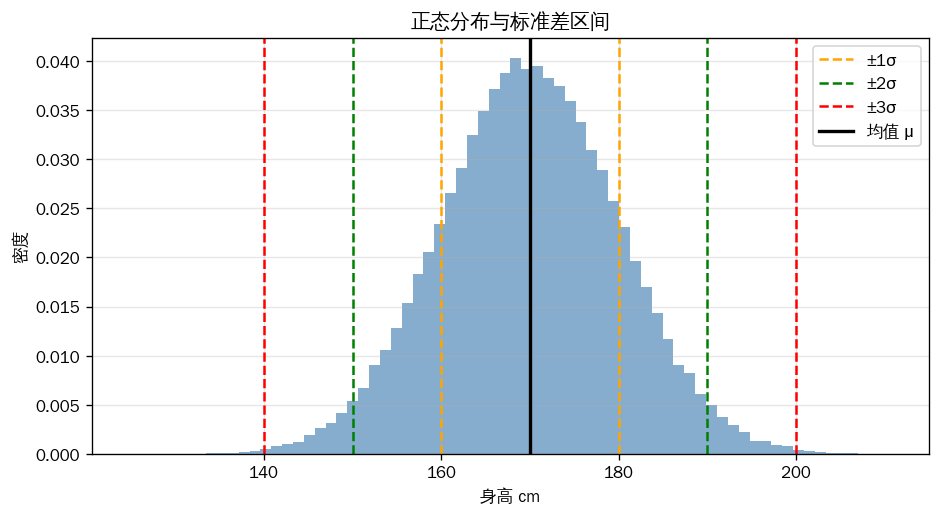

μ±1σ 内比例: 68.22%（理论约 68.3%）
μ±2σ 内比例: 95.42%（理论约 95.4%）
μ±3σ 内比例: 99.72%（理论约 99.7%）


In [16]:
# 正态分布的 68-95-99.7 规则
mu, sigma = 170, 10
heights = rng.normal(mu, sigma, size=100_000)

within_1 = np.mean(np.abs(heights - mu) <= sigma)
within_2 = np.mean(np.abs(heights - mu) <= 2*sigma)
within_3 = np.mean(np.abs(heights - mu) <= 3*sigma)

plt.figure(figsize=(9, 4.5))
plt.hist(heights, bins=70, density=True, alpha=0.65, color='steelblue')
for m, color, label in [(1, 'orange', '±1σ'), (2, 'green', '±2σ'), (3, 'red', '±3σ')]:
    plt.axvline(mu - m*sigma, color=color, ls='--')
    plt.axvline(mu + m*sigma, color=color, ls='--', label=label)
plt.axvline(mu, color='black', lw=2, label='均值 μ')
plt.xlabel('身高 cm')
plt.ylabel('密度')
plt.title('正态分布与标准差区间')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'μ±1σ 内比例: {within_1:.2%}（理论约 68.3%）')
print(f'μ±2σ 内比例: {within_2:.2%}（理论约 95.4%）')
print(f'μ±3σ 内比例: {within_3:.2%}（理论约 99.7%）')

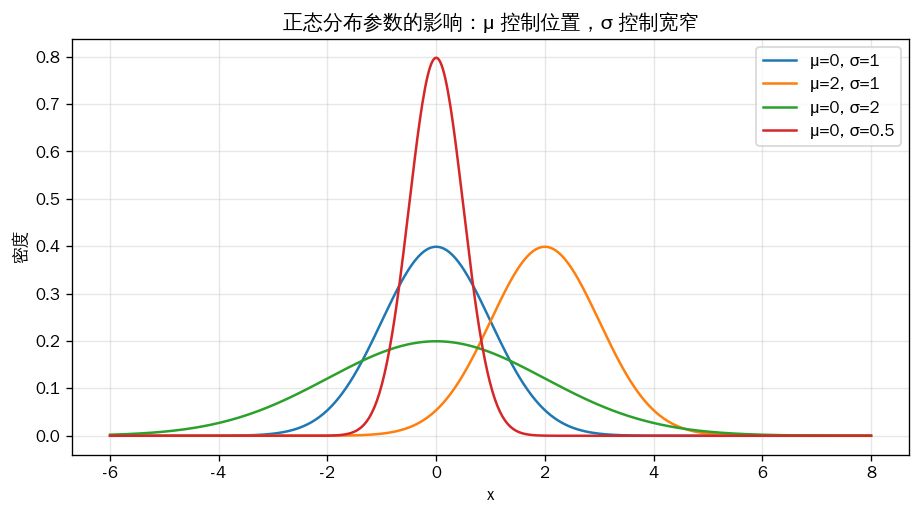

In [17]:
# 均值和标准差如何改变正态分布形状？
def normal_pdf(x, mu, sigma):
    return 1 / (np.sqrt(2*np.pi) * sigma) * np.exp(-0.5 * ((x-mu)/sigma)**2)

x = np.linspace(-6, 8, 600)
configs = [(0, 1), (2, 1), (0, 2), (0, 0.5)]

plt.figure(figsize=(9, 4.5))
for m, s in configs:
    plt.plot(x, normal_pdf(x, m, s), label=f'μ={m}, σ={s}')
plt.xlabel('x')
plt.ylabel('密度')
plt.title('正态分布参数的影响：μ 控制位置，σ 控制宽窄')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.4 Softmax：把模型分数变成概率分布

分类模型常输出一组未归一化分数，称为 logits。Softmax 将 logits 转成概率：

$$
\mathrm{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

性质：

1. 每个输出都在 $(0,1)$ 之间
2. 所有输出之和为 1
3. logit 越大，对应概率越大
4. 给所有 logits 同时加同一个常数，softmax 不变

工程上通常先减去最大 logit，避免指数溢出：

$$
\mathrm{softmax}(z)=\mathrm{softmax}(z-\max(z))
$$

logits: [2.  1.  0.1]
softmax 概率: [0.659  0.2424 0.0986]
概率和: 1.0


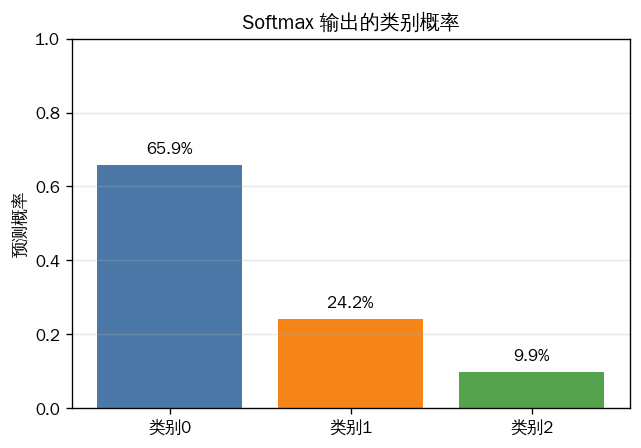

In [18]:
def softmax(z):
    z = np.asarray(z, dtype=float)
    exp_z = np.exp(z - np.max(z))
    return exp_z / exp_z.sum()

logits = np.array([2.0, 1.0, 0.1])
probs = softmax(logits)

print('logits:', logits)
print('softmax 概率:', probs)
print('概率和:', probs.sum())

plt.figure(figsize=(6, 4))
plt.bar(['类别0', '类别1', '类别2'], probs, color=['#4C78A8', '#F58518', '#54A24B'])
plt.ylim(0, 1)
plt.ylabel('预测概率')
plt.title('Softmax 输出的类别概率')
for i, v in enumerate(probs):
    plt.text(i, v + 0.03, f'{v:.1%}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

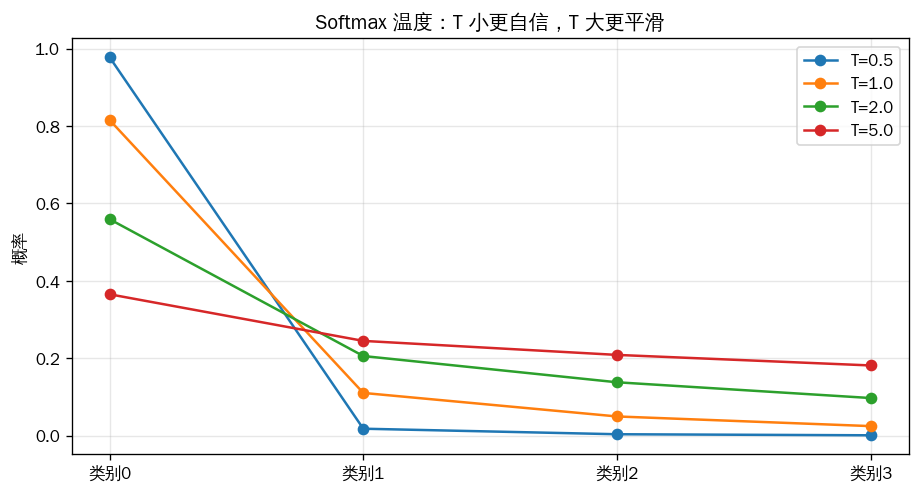

In [19]:
# 温度参数 temperature：控制分布的尖锐程度
base_logits = np.array([3.0, 1.0, 0.2, -0.5])
temperatures = [0.5, 1.0, 2.0, 5.0]

plt.figure(figsize=(9, 4.5))
for T in temperatures:
    p_T = softmax(base_logits / T)
    plt.plot(range(len(base_logits)), p_T, marker='o', label=f'T={T}')
plt.xticks(range(len(base_logits)), [f'类别{i}' for i in range(len(base_logits))])
plt.ylabel('概率')
plt.title('Softmax 温度：T 小更自信，T 大更平滑')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. 期望、方差与标准差：分布的摘要

一个完整分布可能很复杂，但我们经常先看两个摘要：

**期望**：长期平均值

$$
E[X]=\sum_i x_iP(x_i)
$$

**方差**：数据围绕均值的平均平方偏离

$$
\mathrm{Var}(X)=E[(X-E[X])^2]
$$

**标准差**：方差开根号，单位和原始变量一致

$$
\sigma=\sqrt{\mathrm{Var}(X)}
$$

直觉：

- 均值回答“中心在哪里”
- 方差/标准差回答“分散到什么程度”

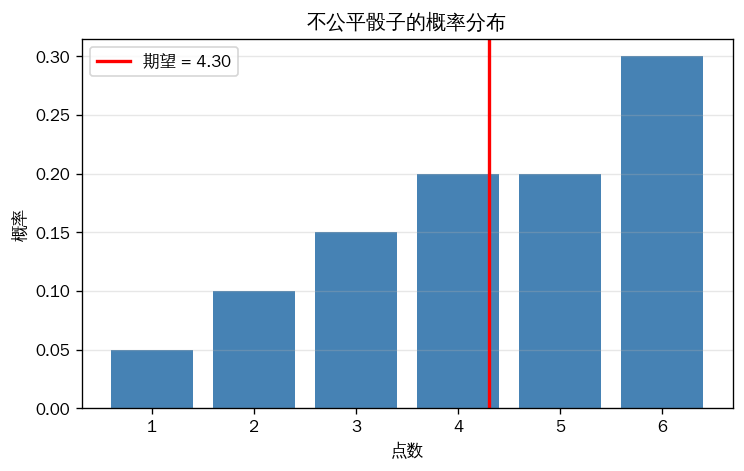

期望 E[X] = 4.300
方差 Var(X) = 2.310
标准差 Std(X) = 1.520


In [20]:
# 离散分布的期望和方差：不公平骰子
values = np.array([1, 2, 3, 4, 5, 6])
probs = np.array([0.05, 0.10, 0.15, 0.20, 0.20, 0.30])

expected = np.sum(values * probs)
variance = np.sum((values - expected)**2 * probs)
std = np.sqrt(variance)

plt.figure(figsize=(7, 4))
plt.bar(values, probs, color='steelblue')
plt.axvline(expected, color='red', lw=2, label=f'期望 = {expected:.2f}')
plt.xlabel('点数')
plt.ylabel('概率')
plt.title('不公平骰子的概率分布')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f'期望 E[X] = {expected:.3f}')
print(f'方差 Var(X) = {variance:.3f}')
print(f'标准差 Std(X) = {std:.3f}')

### 5.1 均值相同，方差可以完全不同

只看平均值可能误导。两个班平均分都可能是 80，但一个班所有人都接近 80，另一个班两极分化严重。

这就是方差的作用：描述不确定性和离散程度。

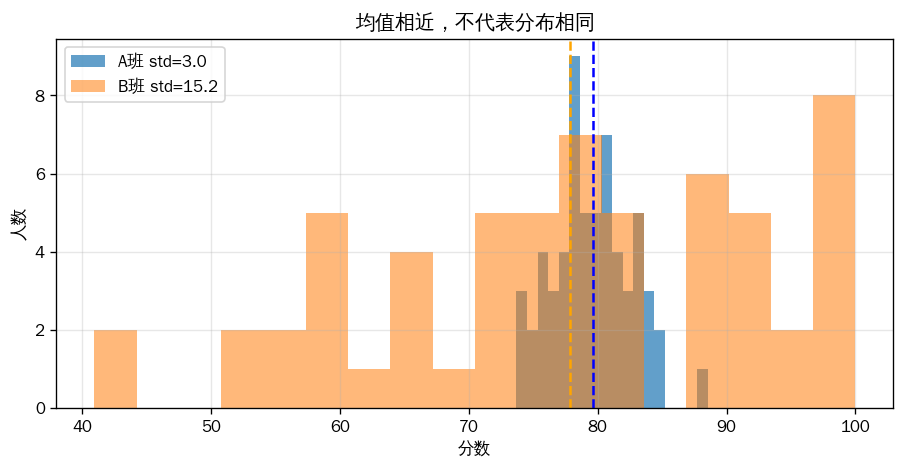

A班均值: 79.62, 标准差: 3.00
B班均值: 77.85, 标准差: 15.22


In [21]:
# 两组数据均值接近，但分散程度不同
class_a = rng.normal(80, 3, size=60)
class_b = rng.normal(80, 15, size=60)
class_a = np.clip(class_a, 0, 100)
class_b = np.clip(class_b, 0, 100)

plt.figure(figsize=(9, 4))
plt.hist(class_a, bins=18, alpha=0.7, label=f'A班 std={class_a.std():.1f}')
plt.hist(class_b, bins=18, alpha=0.55, label=f'B班 std={class_b.std():.1f}')
plt.axvline(class_a.mean(), color='blue', ls='--')
plt.axvline(class_b.mean(), color='orange', ls='--')
plt.xlabel('分数')
plt.ylabel('人数')
plt.title('均值相近，不代表分布相同')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'A班均值: {class_a.mean():.2f}, 标准差: {class_a.std():.2f}')
print(f'B班均值: {class_b.mean():.2f}, 标准差: {class_b.std():.2f}')

### 5.2 Z-Score 标准化：让不同尺度的特征可比较

机器学习中，不同特征的尺度可能差别很大：

- 身高：150 到 190 cm
- 年收入：几万到几十万
- 年龄：十几到几十岁

如果直接用距离或梯度优化，大尺度特征可能主导模型。

Z-Score 标准化：

$$
z=\frac{x-\mu}{\sigma}
$$

变换后：

- 均值约为 0
- 标准差约为 1
- 数值含义变成“离均值几个标准差”

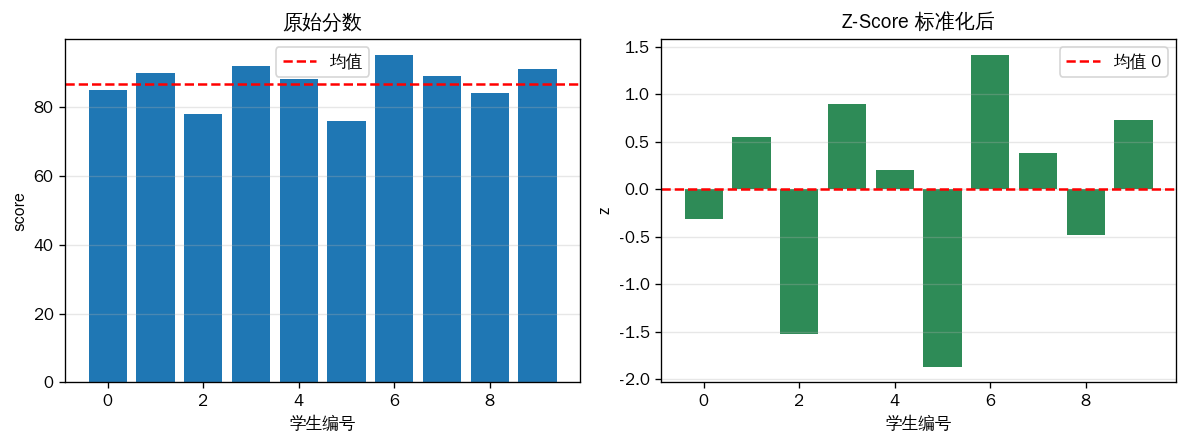

原始数据: [85 90 78 92 88 76 95 89 84 91]
标准化后: [-0.312  0.554 -1.524  0.9    0.208 -1.87   1.42   0.381 -0.485  0.727]
标准化后均值: 0.0000000000
标准化后标准差: 1.0000000000


In [22]:
# 标准化前后对比
scores = np.array([85, 90, 78, 92, 88, 76, 95, 89, 84, 91])
z = (scores - scores.mean()) / scores.std()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(range(len(scores)), scores)
axes[0].axhline(scores.mean(), color='red', ls='--', label='均值')
axes[0].set_title('原始分数')
axes[0].set_ylabel('score')
axes[0].legend()

axes[1].bar(range(len(z)), z, color='seagreen')
axes[1].axhline(0, color='red', ls='--', label='均值 0')
axes[1].set_title('Z-Score 标准化后')
axes[1].set_ylabel('z')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('学生编号')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('原始数据:', scores)
print('标准化后:', np.round(z, 3))
print(f'标准化后均值: {z.mean():.10f}')
print(f'标准化后标准差: {z.std():.10f}')

## 6. 抽样误差与中心极限定理

统计学习通常只能看到有限样本，而不是完整总体。

因此同一个总体中抽出不同样本，样本均值会有波动，这叫抽样误差。

中心极限定理告诉我们：在很多条件下，样本均值的分布会随着样本量增大而接近正态分布，即使原始数据本身不是正态分布。

这解释了为什么正态分布在统计推断中如此常见。

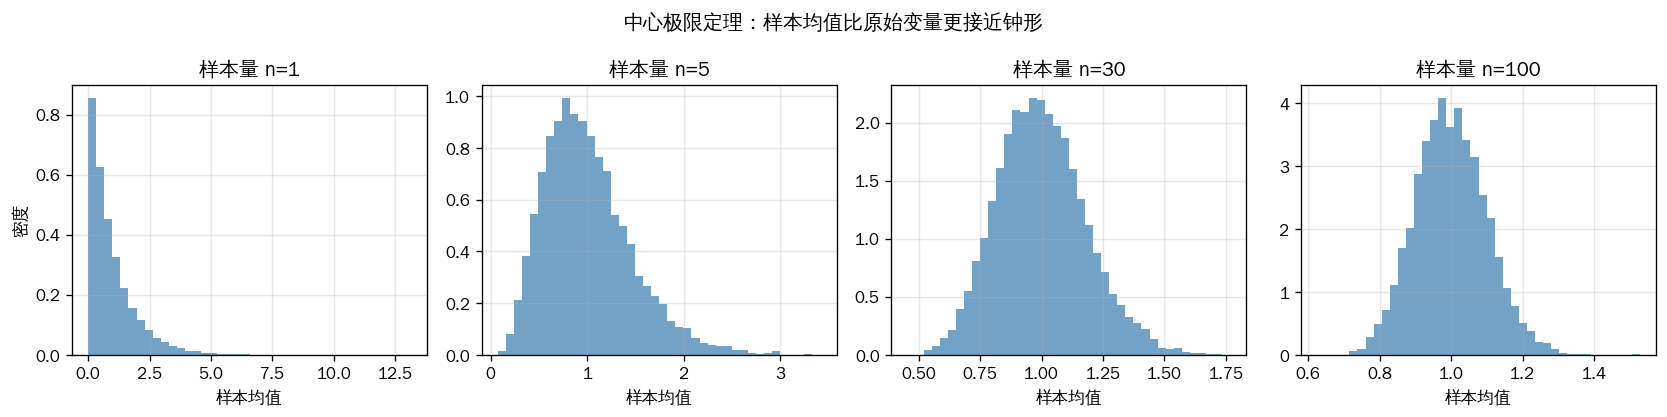

In [23]:
# 从指数分布中抽样：原始分布明显右偏，但样本均值逐渐接近正态
sample_sizes = [1, 5, 30, 100]
num_experiments = 8000

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, m in zip(axes, sample_sizes):
    sample_means = rng.exponential(scale=1.0, size=(num_experiments, m)).mean(axis=1)
    ax.hist(sample_means, bins=40, density=True, alpha=0.75, color='steelblue')
    ax.set_title(f'样本量 n={m}')
    ax.set_xlabel('样本均值')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('密度')
plt.suptitle('中心极限定理：样本均值比原始变量更接近钟形')
plt.tight_layout()
plt.show()

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


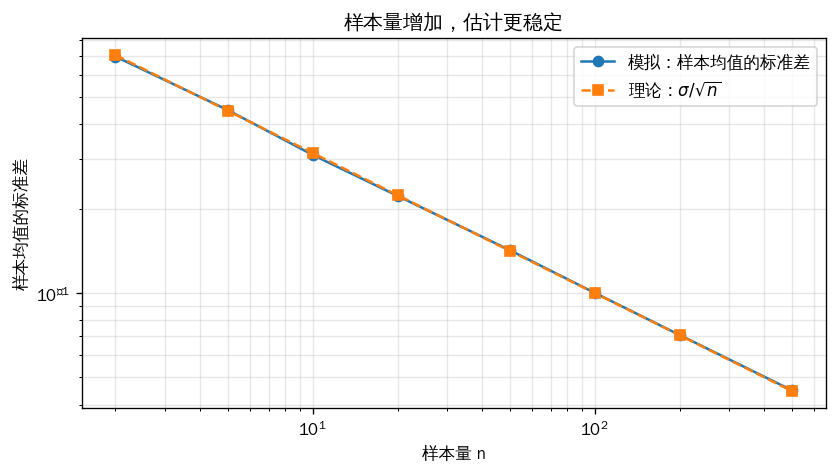

In [24]:
# 样本量越大，样本均值越稳定：标准误约为 sigma / sqrt(n)
true_sigma = 1.0  # 指数分布 scale=1 的标准差
sizes = np.array([2, 5, 10, 20, 50, 100, 200, 500])
empirical_std = []
for m in sizes:
    means = rng.exponential(scale=1.0, size=(5000, m)).mean(axis=1)
    empirical_std.append(means.std())
empirical_std = np.array(empirical_std)
theory_se = true_sigma / np.sqrt(sizes)

plt.figure(figsize=(8, 4))
plt.plot(sizes, empirical_std, 'o-', label='模拟：样本均值的标准差')
plt.plot(sizes, theory_se, 's--', label=r'理论：$\sigma/\sqrt{n}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('样本量 n')
plt.ylabel('样本均值的标准差')
plt.title('样本量增加，估计更稳定')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

## 7. 最大似然估计：选择最能解释数据的参数

最大似然估计（Maximum Likelihood Estimation, MLE）回答：

> 给定已经观察到的数据，哪个参数最有可能产生这些数据？

如果抛硬币 $n$ 次，观察到 $k$ 次正面，正面概率为 $p$ 的似然为：

$$
L(p)=P(\text{数据}|p)=\binom{n}{k}p^k(1-p)^{n-k}
$$

通常最大化对数似然：

$$
\log L(p)=k\log p+(n-k)\log(1-p)+\text{const}
$$

它的最大值在：

$$
\hat p=\frac{k}{n}
$$

机器学习中的很多训练目标，本质上就是最大化训练数据在模型下的似然，或者等价地最小化负对数似然。

/home/hong/testcode/machine_learning_demo/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) WenQuanYi Zen Hei.
  fig.canvas.print_figure(bytes_io, **kw)


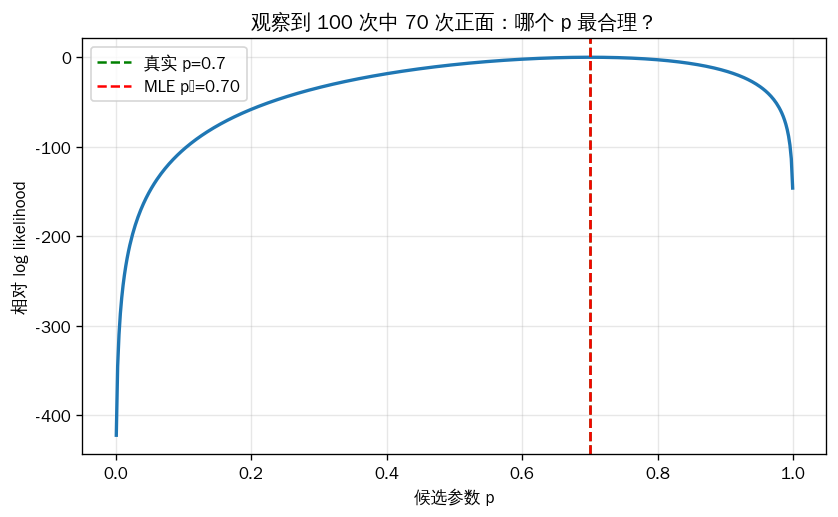

真实 p: 0.7
观察到正面次数 k: 70/100
MLE 估计 p̂=k/n: 0.7000


In [25]:
# MLE 示例：估计硬币正面概率
true_p = 0.7
n_flips = 100
flips = rng.binomial(1, true_p, size=n_flips)
k = flips.sum()
mle_p = k / n_flips

p_grid = np.linspace(0.001, 0.999, 500)
log_likelihood = k * np.log(p_grid) + (n_flips - k) * np.log(1 - p_grid)
log_likelihood_shifted = log_likelihood - log_likelihood.max()

plt.figure(figsize=(8, 4.5))
plt.plot(p_grid, log_likelihood_shifted, lw=2)
plt.axvline(true_p, color='green', ls='--', label=f'真实 p={true_p}')
plt.axvline(mle_p, color='red', ls='--', label=f'MLE p̂={mle_p:.2f}')
plt.xlabel('候选参数 p')
plt.ylabel('相对 log likelihood')
plt.title(f'观察到 {n_flips} 次中 {k} 次正面：哪个 p 最合理？')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'真实 p: {true_p}')
print(f'观察到正面次数 k: {k}/{n_flips}')
print(f'MLE 估计 p̂=k/n: {mle_p:.4f}')

### 7.1 样本量越大，MLE 越稳定

MLE 不是每次都等于真实参数，因为数据有随机性。

但随着样本量增加，估计通常会更集中在真实值附近。

/tmp/ipykernel_1283592/2915044268.py:16: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) WenQuanYi Zen Hei.
  plt.tight_layout()


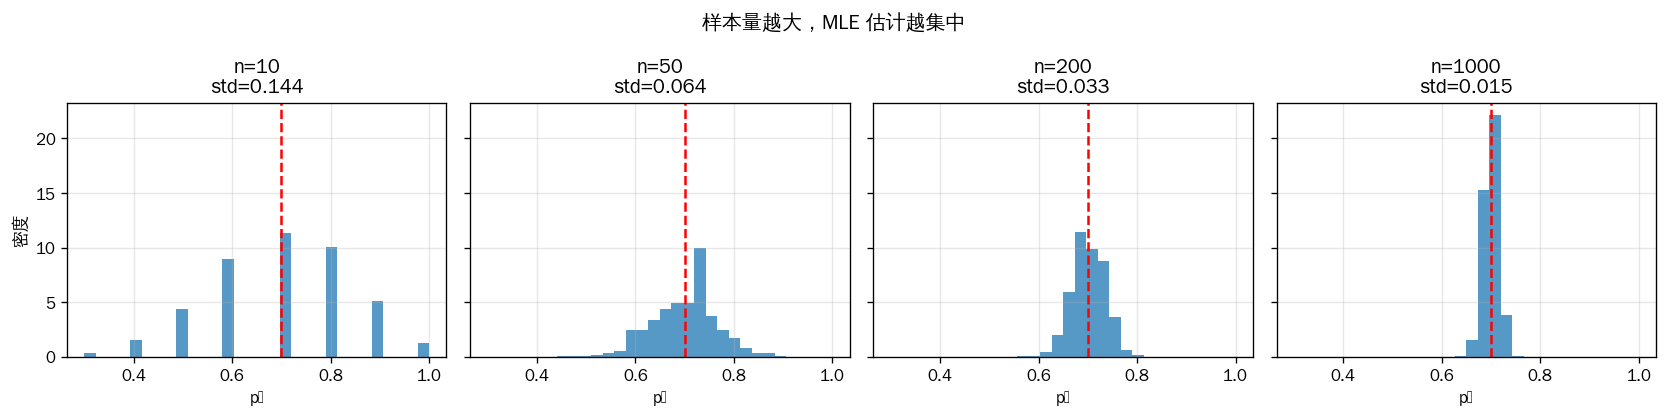

In [26]:
# 重复很多次实验，看 MLE 的分布如何随样本量变化
true_p = 0.7
sizes = [10, 50, 200, 1000]
repeats = 5000

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, n in zip(axes, sizes):
    estimates = rng.binomial(n, true_p, size=repeats) / n
    ax.hist(estimates, bins=30, range=(0.3, 1.0), density=True, alpha=0.75)
    ax.axvline(true_p, color='red', ls='--')
    ax.set_title(f'n={n}\nstd={estimates.std():.3f}')
    ax.set_xlabel('p̂')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('密度')
plt.suptitle('样本量越大，MLE 估计越集中')
plt.tight_layout()
plt.show()

### 7.2 正态分布参数的 MLE

如果假设数据来自正态分布：

$$
X \sim \mathcal{N}(\mu,\sigma^2)
$$

那么 MLE 给出的均值估计是样本均值：

$$
\hat\mu=\frac{1}{n}\sum_i x_i
$$

方差的 MLE 是：

$$
\hat\sigma^2=\frac{1}{n}\sum_i(x_i-\hat\mu)^2
$$

注意：统计学中常见的无偏样本方差会除以 $n-1$，而 MLE 方差除以 $n$。两者目标不同。

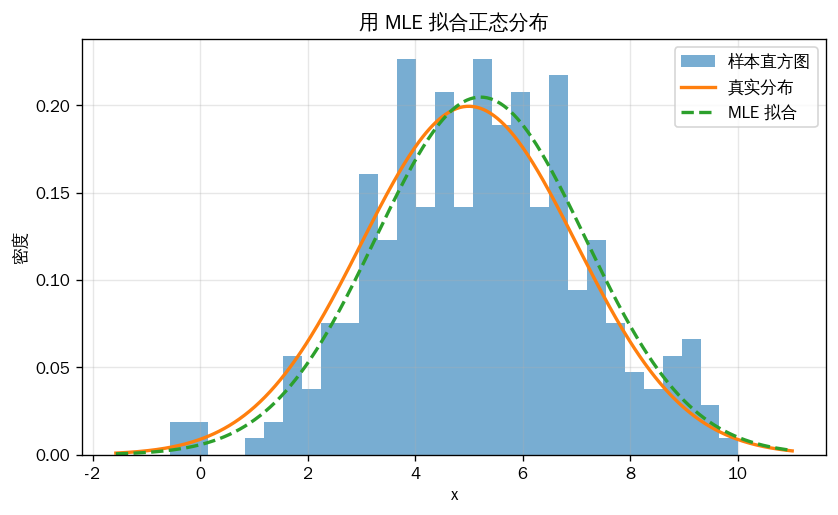

真实 μ=5.00, σ=2.00
MLE  μ̂=5.22, σ̂=1.95
无偏样本标准差 ddof=1: 1.95


In [27]:
# 正态分布 MLE：估计 μ 和 σ
true_mu, true_sigma = 5.0, 2.0
x = rng.normal(true_mu, true_sigma, size=300)
mu_hat = x.mean()
sigma_hat_mle = np.sqrt(np.mean((x - mu_hat)**2))
sigma_hat_unbiased = x.std(ddof=1)

xs = np.linspace(x.min()-1, x.max()+1, 400)

def norm_pdf(x, mu, sigma):
    return 1/(np.sqrt(2*np.pi)*sigma) * np.exp(-0.5*((x-mu)/sigma)**2)

plt.figure(figsize=(8, 4.5))
plt.hist(x, bins=30, density=True, alpha=0.6, label='样本直方图')
plt.plot(xs, norm_pdf(xs, true_mu, true_sigma), label='真实分布', lw=2)
plt.plot(xs, norm_pdf(xs, mu_hat, sigma_hat_mle), '--', label='MLE 拟合', lw=2)
plt.xlabel('x')
plt.ylabel('密度')
plt.title('用 MLE 拟合正态分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'真实 μ={true_mu:.2f}, σ={true_sigma:.2f}')
print(f'MLE  μ̂={mu_hat:.2f}, σ̂={sigma_hat_mle:.2f}')
print(f'无偏样本标准差 ddof=1: {sigma_hat_unbiased:.2f}')

## 8. 信息论：信息量、熵与交叉熵

信息论提供了衡量“不确定性”和“预测质量”的语言。

一个事件的信息量定义为：

$$
I(x)=-\log_2 P(x)
$$

直觉：

- 高概率事件发生，不意外，信息量小
- 低概率事件发生，很意外，信息量大

例如：

- “太阳从东方升起”：概率接近 1，信息量接近 0
- “彩票中大奖”：概率极低，信息量很大

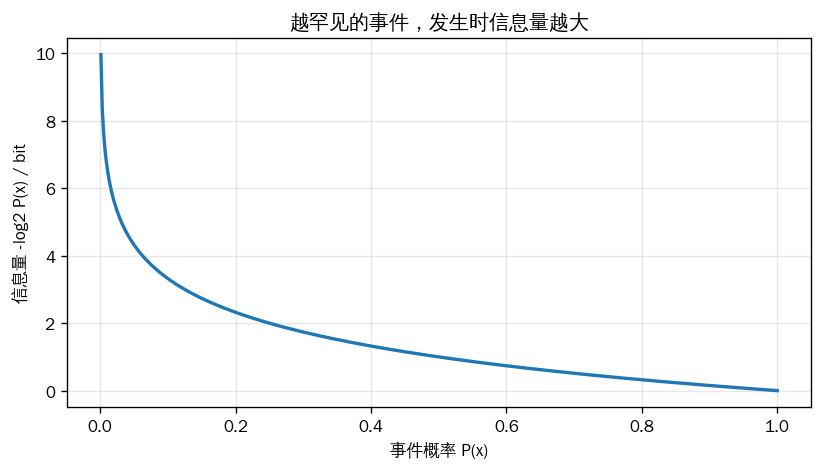

P=  0.5: 信息量=1.00 bit
P=  0.1: 信息量=3.32 bit
P= 0.01: 信息量=6.64 bit
P=0.001: 信息量=9.97 bit


In [28]:
# 信息量随概率变化
ps = np.linspace(0.001, 1, 500)
info = -np.log2(ps)

plt.figure(figsize=(8, 4))
plt.plot(ps, info, lw=2)
plt.xlabel('事件概率 P(x)')
plt.ylabel('信息量 -log2 P(x) / bit')
plt.title('越罕见的事件，发生时信息量越大')
plt.grid(alpha=0.3)
plt.show()

for p in [0.5, 0.1, 0.01, 0.001]:
    print(f'P={p:>5}: 信息量={-np.log2(p):.2f} bit')

### 8.1 熵：一个分布的平均不确定性

熵是信息量的期望：

$$
H(P)=-\sum_x P(x)\log_2 P(x)
$$

直觉：

- 分布越均匀，越难猜，熵越大
- 分布越集中，越容易猜，熵越小

公平硬币的熵是 1 bit，因为每次抛硬币平均需要 1 个二进制问题来确定结果。

In [29]:
def entropy(probs, base=2):
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]
    log = np.log2 if base == 2 else np.log
    return -np.sum(probs * log(probs))

examples = {
    '公平硬币 [0.5,0.5]': [0.5, 0.5],
    '偏硬币 [0.99,0.01]': [0.99, 0.01],
    '公平骰子': [1/6]*6,
    '四分类均匀': [0.25]*4,
    '几乎确定': [0.97, 0.01, 0.01, 0.01],
}

for name, p in examples.items():
    print(f'{name:<22} 熵 = {entropy(p):.4f} bit')

公平硬币 [0.5,0.5]         熵 = 1.0000 bit
偏硬币 [0.99,0.01]        熵 = 0.0808 bit
公平骰子                   熵 = 2.5850 bit
四分类均匀                  熵 = 2.0000 bit
几乎确定                   熵 = 0.2419 bit


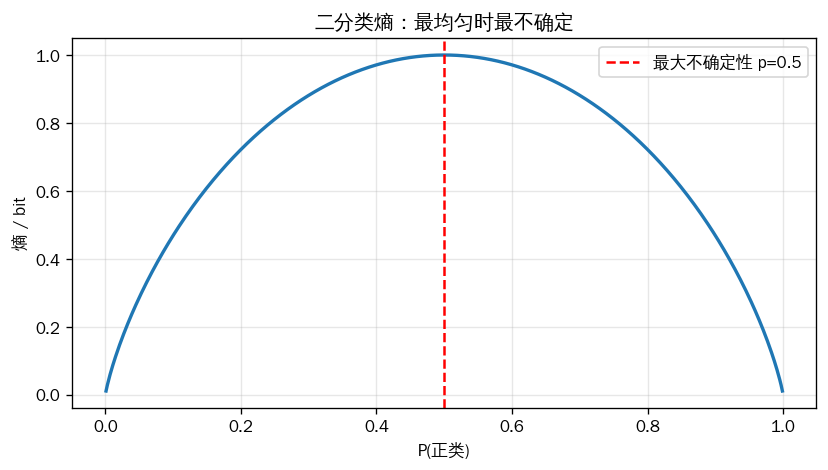

In [30]:
# 二分类熵 H(p, 1-p) 在 p=0.5 最大
ps = np.linspace(0.001, 0.999, 500)
Hs = np.array([entropy([p, 1-p]) for p in ps])

plt.figure(figsize=(8, 4))
plt.plot(ps, Hs, lw=2)
plt.axvline(0.5, color='red', ls='--', label='最大不确定性 p=0.5')
plt.xlabel('P(正类)')
plt.ylabel('熵 / bit')
plt.title('二分类熵：最均匀时最不确定')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 8.2 交叉熵：用预测分布编码真实数据的代价

交叉熵定义为：

$$
H(P,Q)=-\sum_x P(x)\log Q(x)
$$

其中：

- $P$：真实分布
- $Q$：模型预测分布

在分类任务中，真实标签常是 one-hot。例如真实类别是第 3 类：

$$
P=[0,0,1,0]
$$

如果模型预测：

$$
Q=[0.05,0.05,0.85,0.05]
$$

交叉熵就是：

$$
-\log(0.85)
$$

所以，模型给正确类别的概率越高，损失越小。

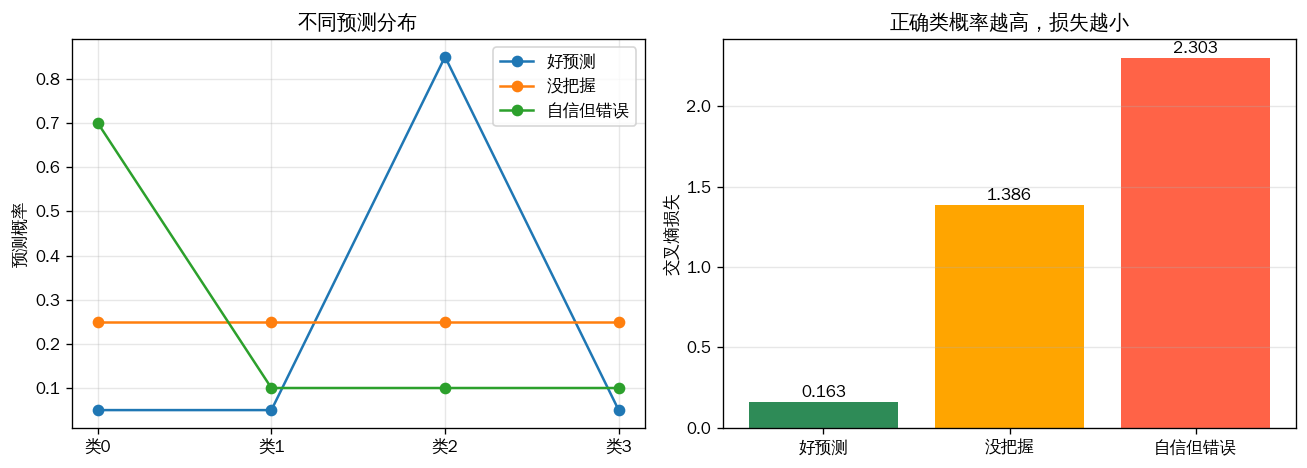

好预测      CE = 0.1625
没把握      CE = 1.3863
自信但错误    CE = 2.3026


In [31]:
def cross_entropy(p_true, q_pred):
    p_true = np.asarray(p_true, dtype=float)
    q_pred = np.asarray(q_pred, dtype=float)
    q_pred = np.clip(q_pred, 1e-15, 1.0)
    return -np.sum(p_true * np.log(q_pred))

y_true = np.array([0, 0, 1, 0])
predictions = {
    '好预测': np.array([0.05, 0.05, 0.85, 0.05]),
    '没把握': np.array([0.25, 0.25, 0.25, 0.25]),
    '自信但错误': np.array([0.70, 0.10, 0.10, 0.10]),
}

names = list(predictions.keys())
losses = [cross_entropy(y_true, predictions[name]) for name in names]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, q in predictions.items():
    axes[0].plot(range(4), q, marker='o', label=name)
axes[0].set_xticks(range(4), [f'类{i}' for i in range(4)])
axes[0].set_ylabel('预测概率')
axes[0].set_title('不同预测分布')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(names, losses, color=['seagreen', 'orange', 'tomato'])
axes[1].set_ylabel('交叉熵损失')
axes[1].set_title('正确类概率越高，损失越小')
for i, v in enumerate(losses):
    axes[1].text(i, v + 0.03, f'{v:.3f}', ha='center')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

for name, loss in zip(names, losses):
    print(f'{name:<8} CE = {loss:.4f}')

### 8.3 二分类交叉熵：逻辑回归和神经网络常用损失

对于二分类标签 $y\in\{0,1\}$，模型预测正类概率 $p$，二分类交叉熵为：

$$
\mathrm{BCE}(y,p)=-[y\log p+(1-y)\log(1-p)]
$$

如果真实标签是 1：

$$
\mathrm{BCE}=-\log p
$$

如果真实标签是 0：

$$
\mathrm{BCE}=-\log(1-p)
$$

它会惩罚“自信但错误”的预测。

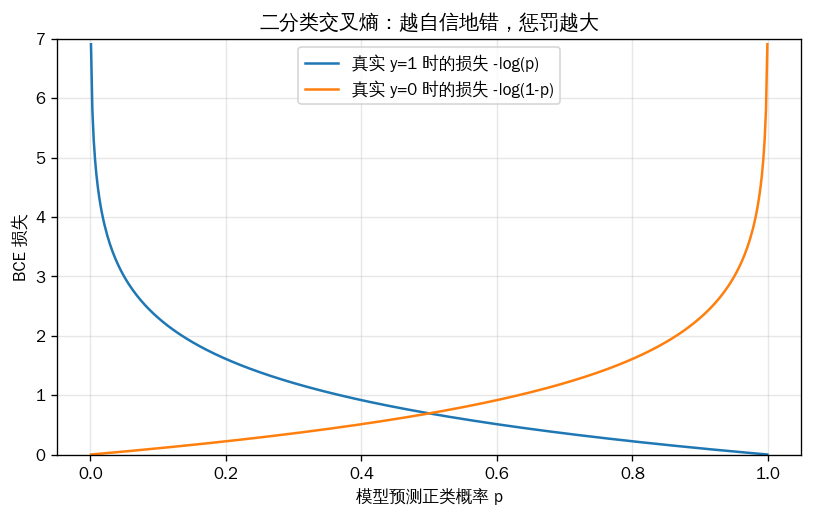

In [32]:
def binary_cross_entropy(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y*np.log(p) + (1-y)*np.log(1-p))

p_grid = np.linspace(0.001, 0.999, 500)
loss_y1 = binary_cross_entropy(1, p_grid)
loss_y0 = binary_cross_entropy(0, p_grid)

plt.figure(figsize=(8, 4.5))
plt.plot(p_grid, loss_y1, label='真实 y=1 时的损失 -log(p)')
plt.plot(p_grid, loss_y0, label='真实 y=0 时的损失 -log(1-p)')
plt.xlabel('模型预测正类概率 p')
plt.ylabel('BCE 损失')
plt.ylim(0, 7)
plt.title('二分类交叉熵：越自信地错，惩罚越大')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
# 一个小批量的 BCE 计算
y = np.array([1, 0, 1, 1, 0])
p_good = np.array([0.9, 0.1, 0.8, 0.95, 0.05])
p_bad = np.array([0.5, 0.5, 0.5, 0.5, 0.5])
p_wrong = np.array([0.1, 0.9, 0.2, 0.1, 0.95])

for name, p in [('好预测', p_good), ('没把握', p_bad), ('错误预测', p_wrong)]:
    losses = binary_cross_entropy(y, p)
    print(name)
    print('  单样本损失:', np.round(losses, 3))
    print('  平均 BCE:', losses.mean().round(4))

好预测
  单样本损失: [0.105 0.105 0.223 0.051 0.051]
  平均 BCE: 0.1073
没把握
  单样本损失: [0.693 0.693 0.693 0.693 0.693]
  平均 BCE: 0.6931
错误预测
  单样本损失: [2.303 2.303 1.609 2.303 2.996]
  平均 BCE: 2.3026


## 9. 从概率到机器学习：一条主线

现在可以把本节知识串起来：

1. 数据不是固定公式生成的，而带有随机性，所以需要概率分布
2. 模型输出 logits，经过 softmax/sigmoid 变成概率
3. 训练目标可以解释为：让真实标签在模型预测分布下的概率尽可能大
4. 最大化似然等价于最小化负对数似然
5. 对分类任务，负对数似然就对应交叉熵损失

一句话：

> 训练分类模型，就是不断调整参数，让模型对真实类别给出更高概率，从而降低交叉熵。

类别: ['猫', '狗', '鸟']
logits: [ 1.2  2.4 -0.3]
softmax 概率: [0.2201 0.7308 0.0491]
真实类别: 狗
交叉熵损失 = -log(P(真实类别)) = 0.3136


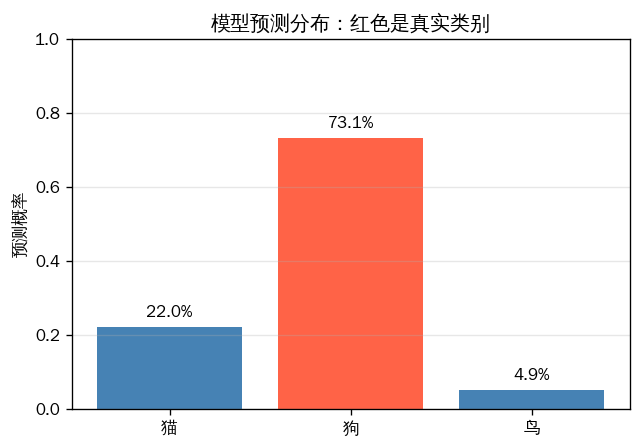

In [34]:
# 一个极简“模型输出 logits -> softmax -> 交叉熵”的完整流程
class_names = ['猫', '狗', '鸟']
logits = np.array([1.2, 2.4, -0.3])
probs = softmax(logits)
true_class = 1  # 狗
one_hot = np.eye(3)[true_class]
loss = cross_entropy(one_hot, probs)

print('类别:', class_names)
print('logits:', logits)
print('softmax 概率:', np.round(probs, 4))
print('真实类别:', class_names[true_class])
print('交叉熵损失 = -log(P(真实类别)) =', loss.round(4))

plt.figure(figsize=(6, 4))
colors = ['steelblue'] * 3
colors[true_class] = 'tomato'
plt.bar(class_names, probs, color=colors)
plt.ylabel('预测概率')
plt.ylim(0, 1)
plt.title('模型预测分布：红色是真实类别')
for i, v in enumerate(probs):
    plt.text(i, v + 0.03, f'{v:.1%}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 10. 常见误区与检查清单

### 常见误区

1. **把 $P(A|B)$ 和 $P(B|A)$ 混为一谈**  
   医学检测、垃圾邮件识别、搜索推荐中都很容易犯这个错误。

2. **认为模拟概率必须精确等于理论概率**  
   样本有限时会有波动；样本越大通常越接近。

3. **把概率密度当成概率**  
   连续分布中，某一点的概率通常是 0；区间下的面积才是概率。

4. **只看均值，不看方差和分布形状**  
   均值相同的两组数据，风险和不确定性可能完全不同。

5. **忘记对 softmax 做数值稳定处理**  
   实现时应使用 `exp(x - max(x))`。

6. **对 log(0) 没有保护**  
   交叉熵实现中通常需要 `clip`，避免出现无穷大或 NaN。

### 学完本节你应该能解释

- 为什么阳性检测不等于 99% 患病概率
- 为什么正态分布中的标准差很重要
- 为什么样本量增大估计会更稳定
- softmax 为什么能输出概率分布
- 最大似然和交叉熵之间有什么关系

## 练习题

1. 修改医学检测例子中的患病率、灵敏度和特异度，观察后验概率如何变化。
2. 把二项分布中的 $p$ 从 0.6 改成 0.1 和 0.9，观察分布形状。
3. 在 Softmax 温度例子中尝试更小的 $T=0.1$，解释为什么概率会接近 one-hot。
4. 用指数分布或均匀分布生成数据，计算样本均值和样本标准差。
5. 写一个函数 `negative_log_likelihood_for_coin(k, n, p)`，返回硬币数据在参数 $p$ 下的负对数似然。
6. 解释为什么交叉熵会惩罚“自信但错误”的分类预测。

下一节：优化基础。你会看到模型如何沿着损失函数的梯度方向更新参数。